In [2]:
%matplotlib widget
import torch
import warnings
import os
import copy
import subprocess
import shlex
import matplotlib.pyplot as plt
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
from torch.profiler import profile,  ProfilerActivity

os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from diffSPH.sampling import buildDomainDescription
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.integration import getIntegrator
from diffSPH.util import volumeToSupport
from diffSPH.boundary import sampleDomainSDF
from diffSPH.kernels import Kernel_Scale
from diffSPH.sdf import getSDF, sdfFunctions, operatorDict, sampleSDF
from diffSPH.regions import buildRegion, filterRegion, plotRegions
from diffSPH.modules.timestep import computeTimestep
from diffSPH.schemes.initializers import initializeSimulation, updateBodyParticles
from diffSPH.schemes.deltaSPH import deltaPlusSPHScheme, DeltaPlusSPHSystem
from diffSPH.schema import getSimulationScheme
from diffSPH.enums import *
# from exampleUtil import setupExampleSimulation, runSimulation, postProcess
from diffSPH.sampling import sampleDivergenceFreeNoise
import math
from diffSPH.sampling import sampleDivergenceFreeNoise
from diffSPH.modules.particleShifting import solveShifting, shuffleParticles
import numpy as np

In [3]:
simulationName = 'Taylor Green Vortex'
k = 2
exportName = f'05_taylorGreenVortex_{k}'
L = 2
nx = 128
dx = L / nx
targetDt = 0.0005
rho0 = 1
freeSurface = False
band = 0
fps = 50
timeLimit = 4

kernel = KernelType.Wendland4
scheme = SimulationScheme.DeltaSPH
integrationScheme = IntegrationSchemeType.symplecticEuler

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32
targetNeighbors = n_h_to_nH(4, 2)
c_s = 0.3 * volumeToSupport(dx**2, targetNeighbors, 2) / Kernel_Scale(kernel, 2) / targetDt
exportInterval = 1 / fps
plotInterval = int(math.ceil(exportInterval / targetDt))
timesteps = int(timeLimit / targetDt)

In [4]:
dim = 2
CFL = 0.3

domain = buildDomainDescription(l = L + dx * (band) * 2, dim = dim, periodic = True, device = device, dtype = dtype)
interiorDomain = buildDomainDescription(l = L, dim = dim, periodic = False, device = device, dtype = dtype)
wrappedKernel = kernel

simulator, SimulationSystem, config, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     1.0, targetNeighbors, domain)
integrationScheme = getIntegrator(integrationScheme)

config['particle'] = {
    'nx': nx + 2 * band,
    'dx': L/nx,
    'targetNeighbors': targetNeighbors,
    'band': band
}
config['fluid'] = {
    'rho0': rho0,
    'c_s': c_s
}
config['surfaceDetection']['active'] = freeSurface
config['shifting']['freeSurface'] = freeSurface

In [5]:
fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)

regions = []
regions.append(buildRegion(sdf = fluid_sdf, config = config, type = 'fluid'))

for region in regions:
    region = filterRegion(region, regions)

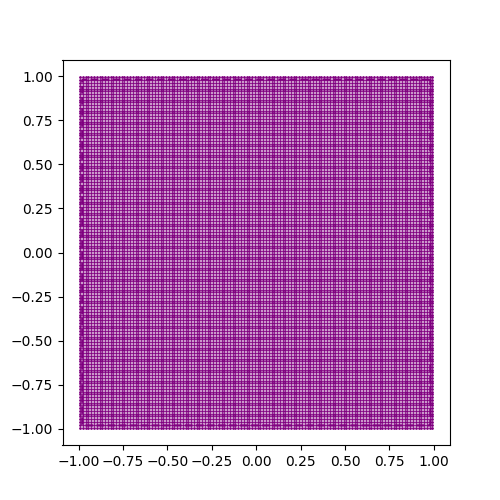

In [6]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)


In [7]:

u_mag = 1

particleState, config, rigidBodies = initializeSimulation(scheme, config, regions)


particleState.positions = shuffleParticles(particleState, config, 4)
k_ = k

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

particleState.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * particleState.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * particleState.positions[:,1] + phaseShift_y)
particleState.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * particleState.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * particleState.positions[:,1] + phaseShift_y)


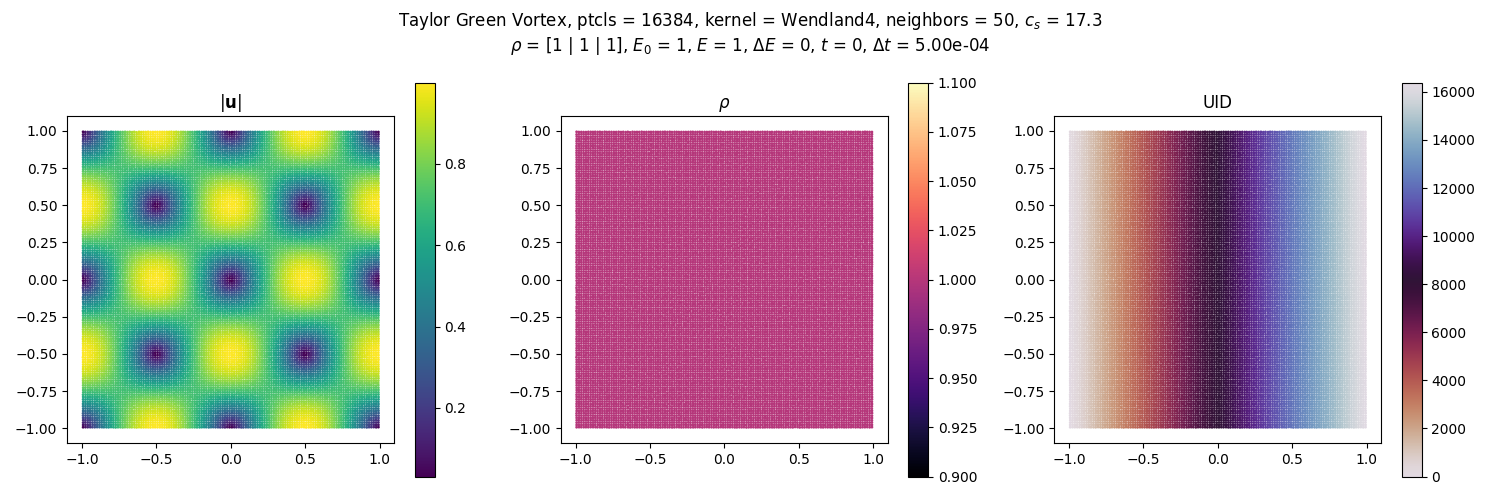

In [9]:
stacked = 'horizontal'
figsize = (15, 5) if stacked == 'horizontal' else (5, 15)
markerSize = 1

dt = computeTimestep(scheme, 1e-2, particleState, config, None)
particles = copy.deepcopy(particleState)
particleSystem = DeltaPlusSPHSystem(config['domain'], None, 0., copy.deepcopy(particleState), 'momentum', None, rigidBodies = config['rigidBodies'], regions = config['regions'], config = config)

for rigidBody in config['rigidBodies']:
    particleState = updateBodyParticles(scheme, particleState, rigidBody)

## Setup values for plotting 

kineticEnergy = 0.5 * particleState.densities * (particleState.velocities ** 2).sum(1)

t = 0
E_k0 = 0.5 * particleState.masses * torch.linalg.norm(particleState.velocities, dim = -1)**2
E_k = 0.5 * particleState.masses * torch.linalg.norm(particleState.velocities, dim = -1)**2

rhoMin = particleState.densities.min().detach().cpu().item() / config['fluid']['rho0']
rhoMean = particleState.densities.mean().detach().cpu().item() / config['fluid']['rho0']
rhoMax = particleState.densities.max().detach().cpu().item() / config['fluid']['rho0']

initialVelocity = particleState.velocities.clone()
initialDensities = particleState.densities.clone()
initialPotentialEnergy = None

if config['gravity']['active']:
    if 'mode' in config['gravity'] and config['gravity']['mode'] == 'potential':
        B = config['gravity']['magnitude']
        initialPotentialEnergy = 0.5 * B**2 * particleState.masses / config['fluid']['rho0'] * particleState.densities * torch.linalg.norm(particleState.positions, dim = -1)**2

initialKineticEnergy = 0.5 * particleState.masses / config['fluid']['rho0'] * particleState.densities * torch.linalg.norm(initialVelocity, dim = -1)**2
initialEnergy = initialKineticEnergy + initialPotentialEnergy if initialPotentialEnergy is not None else initialKineticEnergy

if stacked == 'horizontal':
    fig, axis = plt.subplots(1, 3, figsize = figsize, squeeze=False)
elif stacked == 'vertical':
    fig, axis = plt.subplots(3, 1, figsize = figsize, squeeze=False)
else:
    raise ValueError(f"Invalid value for 'stacked': {stacked}. Expected 'horizontal' or 'vertical'.")

axes = axis.flatten()

# markerSize = 1
velocityPlot = visualizeParticles(fig, axes[0], 
            particles = particleSystem.systemState, 
            domain = config['domain'], 
            quantity = particleSystem.systemState.velocities, 
            which = 'fluid',
            mapping = 'L2',
            cmap = 'viridis',
            visualizeBoth=False,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=False, markerSize=markerSize, streamLines=False)

densityPlot = visualizeParticles(fig, axes[1],
            particles = particleSystem.systemState, 
            domain = config['domain'], 
            quantity = particleSystem.systemState.densities, 
            which = 'both',
            # operation = 'curl',
            mapping = '.y',
            cmap = 'magma',
            visualizeBoth=True,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=False, markerSize=markerSize)

uidPlot = visualizeParticles(fig, axes[2],
            particles = particleSystem.systemState, 
            domain = config['domain'], 
            quantity = particleSystem.systemState.UIDs, 
            which = 'fluid',
            mapping = '.x',
            cmap = 'twilight_r',
            visualizeBoth=False,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=False, markerSize=markerSize, streamLines=False)
axis[0,0].set_title(r'$|\mathbf{u}|$')
axis[0,1].set_title(r'$\rho$')
axis[0,2].set_title(r'UID')

totalInitialEnergy = (initialEnergy).sum().detach().cpu().item()
totalEnergy = (initialEnergy).sum().detach().cpu().item()

fig.suptitle(f'{simulationName}, ptcls = {particleState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}\n$\\rho$ = [{rhoMin:.4g} | {rhoMean:.4g} | {rhoMax:.4g}], $E_0$ = {totalInitialEnergy:.4g}, $E$ = {totalEnergy:.4g}, $\\Delta E$ = {totalEnergy - totalInitialEnergy:.4g}, $t$ = {particleSystem.t:.4g}, $\Delta t$ = {dt:.2e}')

fig.tight_layout()

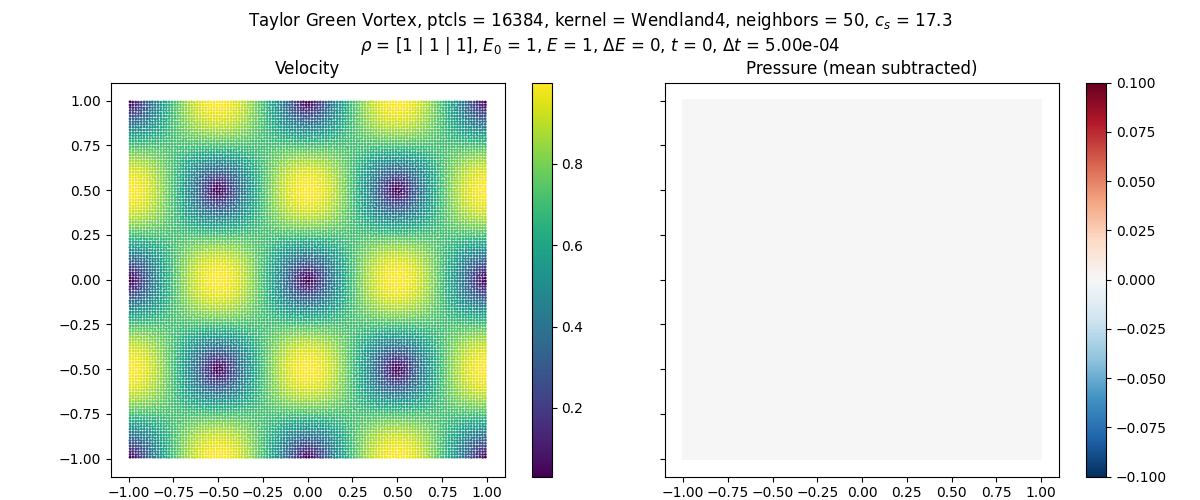

In [10]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze=False, sharey = True)

velocityPlot = visualizeParticles(fig, axis[0,0], 
            particles = particleSystem.systemState, 
            domain = config['domain'], 
            quantity = particleSystem.systemState.velocities, 
            which = 'fluid',
            mapping = 'L2',
            cmap = 'viridis',
            visualizeBoth=False,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=False, markerSize=1, streamLines=False)

pressurePlot = visualizeParticles(fig, axis[0,1], 
            particles = particleSystem.systemState, 
            domain = config['domain'],
            quantity = particleSystem.systemState.pressures - particleSystem.systemState.pressures.mean(),
            which = 'fluid',
            mapping = '.x',
            cmap = 'RdBu_r',
            visualizeBoth=False,
            kernel = config['kernel'],
            plotDomain = False,
            gridVisualization=True, markerSize=3, streamLines=False)

axis[0,0].set_title('Velocity')
axis[0,1].set_title('Pressure (mean subtracted)')

rhoMin = particleSystem.systemState.densities.min().detach().cpu().item() / config['fluid']['rho0']
rhoMean = particleSystem.systemState.densities.mean().detach().cpu().item() / config['fluid']['rho0']
rhoMax = particleSystem.systemState.densities.max().detach().cpu().item() / config['fluid']['rho0']

kineticEnergy = 0.5 * particleSystem.systemState.masses / config['fluid']['rho0'] * particleSystem.systemState.densities * torch.linalg.norm(particleSystem.systemState.velocities, dim = -1)**2
potentialEnergy = None
if config['gravity']['active']:
    if 'mode' in config['gravity'] and config['gravity']['mode'] == 'potential':
        B = config['gravity']['magnitude']
        potentialEnergy = 0.5 * B**2 * particleSystem.systemState.masses / config['fluid']['rho0'] * particleSystem.systemState.densities * torch.linalg.norm(particleSystem.systemState.positions, dim = -1)**2
        
combinedEnergy = kineticEnergy + potentialEnergy if potentialEnergy is not None else kineticEnergy
totalInitialEnergy = (initialEnergy).sum().detach().cpu().item()
totalEnergy = (combinedEnergy).sum().detach().cpu().item()

fig.suptitle(f'{simulationName}, ptcls = {particleSystem.systemState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}\n$\\rho$ = [{rhoMin:.4g} | {rhoMean:.4g} | {rhoMax:.4g}], $E_0$ = {totalInitialEnergy:.4g}, $E$ = {totalEnergy:.4g}, $\\Delta E$ = {totalEnergy - totalInitialEnergy:.4g}, $t$ = {particleSystem.t:.4g}, $\Delta t$ = {dt:.2e}')



fig.tight_layout()



# fig.savefig(f'TGV_ref.png', dpi = 200)
# fig.savefig(f'TGV_ref.pdf', dpi = 200)

# rasterize_and_save(f'TGV_ref.png')
# rasterize_and_save(f'TGV_ref.pdf')

In [13]:
imagePrefix = f'./images/{exportName}/'
os.makedirs(imagePrefix, exist_ok = True)
timesteps = 4000

In [12]:
states = []

In [14]:
# if outFile is not None:
        # outGroup = outFile.create_group('simulationData')
for i in (tq:=tqdm(range(timesteps))):
    particleSystem, currentState, updates = integrationScheme.function(particleSystem, dt, simulator, config, priorStep = particleSystem.priorStep, verbose = False)
    
    # if callBackFn is not None:
        # particleSystem = callBackFn(particleSystem)
    
    # if i % exportInterval == 0:
        # if outFile is not None:
        #     frameGroup = outGroup.create_group(f'{i:06d}')
        #     saveState(particleSystem.systemState, particleSystem.systemState.kinds != 2, frameGroup, config)
        #     if torch.any(particleSystem.systemState.kinds > 0):
        #         frameGroup.create_dataset('normals', data = particleSystem.systemState.ghostOffsets[particleSystem.systemState.kinds != 2])
        #     frameGroup.attrs['t'] = particleSystem.t
        #     frameGroup.attrs['dt'] = dt
        #     frameGroup.attrs['timestep'] = i


    if i % plotInterval == plotInterval - 1 or i == timesteps - 1:

        rhoMin = particleSystem.systemState.densities.min().detach().cpu().item() / config['fluid']['rho0']
        rhoMean = particleSystem.systemState.densities.mean().detach().cpu().item() / config['fluid']['rho0']
        rhoMax = particleSystem.systemState.densities.max().detach().cpu().item() / config['fluid']['rho0']

        kineticEnergy = 0.5 * particleSystem.systemState.masses / config['fluid']['rho0'] * particleSystem.systemState.densities * torch.linalg.norm(particleSystem.systemState.velocities, dim = -1)**2
        potentialEnergy = None
        if config['gravity']['active']:
            if 'mode' in config['gravity'] and config['gravity']['mode'] == 'potential':
                B = config['gravity']['magnitude']
                potentialEnergy = 0.5 * B**2 * particleSystem.systemState.masses / config['fluid']['rho0'] * particleSystem.systemState.densities * torch.linalg.norm(particleSystem.systemState.positions, dim = -1)**2
                
        combinedEnergy = kineticEnergy + potentialEnergy if potentialEnergy is not None else kineticEnergy
        totalInitialEnergy = (initialEnergy).sum().detach().cpu().item()
        totalEnergy = (combinedEnergy).sum().detach().cpu().item()

        fig.suptitle(f'{simulationName}, ptcls = {particleSystem.systemState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}\n$\\rho$ = [{rhoMin:.4g} | {rhoMean:.4g} | {rhoMax:.4g}], $E_0$ = {totalInitialEnergy:.4g}, $E$ = {totalEnergy:.4g}, $\\Delta E$ = {totalEnergy - totalInitialEnergy:.4g}, $t$ = {particleSystem.t:.4g}, $\Delta t$ = {dt:.2e}')
        updatePlot(velocityPlot, particleSystem.systemState, particleSystem.systemState.velocities)
        # updatePlot(densityPlot, particleSystem.systemState, particleSystem.systemState.densities)
        # updatePlot(uidPlot, particleSystem.systemState, particleSystem.systemState.UIDs)
        updatePlot(pressurePlot, particleSystem.systemState, particleSystem.systemState.pressures - particleSystem.systemState.pressures.mean())
        # if plotCallbackFn is not None:
            # plotCallbackFn(fig, axis, particleSystem, i)
        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePrefix}frame_{i:05d}.png', dpi = 200)

        states.append([rhoMin, rhoMean, rhoMax, totalInitialEnergy, totalEnergy, totalEnergy - totalInitialEnergy, particleSystem.t, dt])

  0%|          | 0/4000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [16]:

import imageio

from skimage.transform import resize, rescale
from skimage.io import imread



fileList = os.listdir(imagePrefix)
fileList = [f for f in fileList if f.endswith('.png') and f.startswith('frame_')]
fileList = sorted(fileList)

writer = imageio.get_writer(f'{imagePrefix}/output.mp4', fps=50, bitrate='10M')
for image in fileList:
    writer.append_data(imageio.imread(imagePrefix + image))
writer.close()

images = []
for image in fileList:
    images.append(imread(imagePrefix + image))

currentImageSize = images[0].shape
currentLongEdge = max(images[0].shape[0], images[0].shape[1])
targetLongEdge = 600
ratio = targetLongEdge / currentLongEdge

images = [(rescale(image, ratio, anti_aliasing=True, channel_axis=-1)*255).astype('uint8') for image in images]

# for image in images:
    # print(image.shape)
    # break

# images = [resizeImageLongEdge(i, 600) for i in images]

imageio.mimsave(f'{imagePrefix}/output.gif', images, fps=50)

print('Copying video to videos folder')
os.makedirs(f'./videos/', exist_ok= True)
# subprocess.run(shlex.split(f'cp {imagePrefix}/output.mp4 ./videos/{exportName}.mp4'))
subprocess.run(shlex.split(f'cp {imagePrefix}/output.gif ./videos/{exportName}.gif'))
lastFrameFile = f'{imagePrefix}/frame_{timesteps - 1:05d}.png'
subprocess.run(shlex.split(f'cp {lastFrameFile} ./videos/{exportName}.png'))
print('Done!')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2400, 1000) to (2400, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Copying video to videos folder
Done!


cp: cannot stat './images/05_taylorGreenVortex_2//frame_03999.png': No such file or directory
